### Credit Card Fraud Detection Model Training

#### Overview
This notebook trains and evaluates four machine learning models on
preprocessed credit card transaction data to identify the best model
for fraud detection deployment.

#### Data
- **Source:** Preprocessed by Patrick (EDA phase)
- **Training set:** 16,000 samples (balanced via SMOTE + undersampling)
- **Test set:** 2,086 real world samples (86 fraud, 2,000 legitimate)
- **Features:** 30 PCA transformed transaction features

#### Models Trained
| Model | Key Setting |
|-------|------------|
| Logistic Regression | class_weight='balanced' |
| Random Forest | n_estimators=100, class_weight='balanced' |
| XGBoost | scale_pos_weight for imbalance handling |
| Gradient Boosting | n_estimators=100, learning_rate=0.1 |

#### Evaluation Metrics
- Confusion Matrix
- Precision, Recall, F1-Score
- ROC-AUC Score
- PR-AUC Score (most important for imbalanced data)

#### Results Summary
| Model | ROC-AUC | PR-AUC | False Negatives |
|-------|---------|--------|----------------|
| Logistic Regression | 0.9751 | 0.9106 | 9 |
| **Random Forest** | **0.9899** | **0.9238** | **11** |
| XGBoost | 0.9813 | 0.9115 | 11 |
| Gradient Boosting | 0.9799 | 0.9136 | 11 |

#### Best Model — Random Forest ✅
Random Forest achieved the highest ROC-AUC (0.9899) and PR-AUC (0.9238)
of all four models, with the best precision (0.94) and F1-Score (0.90).
The final model is saved to `../backend/fraud_model.pkl` for deployment
in the FastAPI backend.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load Preprocessed Data from Patrick
X_train = joblib.load('X_train.pkl')
X_test = joblib.load('X_test.pkl')
y_train = joblib.load('y_train.pkl')
y_test = joblib.load('y_test.pkl')

print("✅ Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nClass distribution in y_train:")
print(y_train.value_counts())
print(f"\nClass distribution in y_test:")
print(y_test.value_counts())

✅ Data loaded successfully!
X_train shape: (16000, 30)
X_test shape:  (2086, 30)
y_train shape: (16000,)
y_test shape:  (2086,)

Class distribution in y_train:
Class
0    8000
1    8000
Name: count, dtype: int64

Class distribution in y_test:
Class
0    2000
1      86
Name: count, dtype: int64


In [3]:
# Train Logistic Regression (Baseline)

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully!")

Training Logistic Regression...
✅ Logistic Regression trained successfully!


In [4]:
# Train Random Forest Classifier
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

Training Random Forest...
✅ Random Forest trained successfully!


In [5]:
# Train XGBoost Classifier
print("Training XGBoost...")

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained successfully!")

Training XGBoost...
✅ XGBoost trained successfully!


In [6]:
# Train Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

print("Training Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting trained successfully!")

Training Gradient Boosting...
✅ Gradient Boosting trained successfully!


LOGISTIC REGRESSION EVALUATION

Confusion Matrix:
[[1927   73]
 [   9   77]]


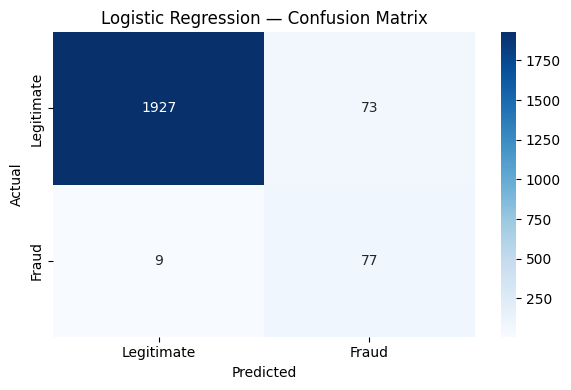


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2000
           1       0.51      0.90      0.65        86

    accuracy                           0.96      2086
   macro avg       0.75      0.93      0.82      2086
weighted avg       0.98      0.96      0.97      2086

ROC-AUC Score:  0.9751
PR-AUC  Score:  0.9106


In [7]:
# Evaluate Logistic Regression
print("LOGISTIC REGRESSION EVALUATION")
print("="*50)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)
print(f"\nConfusion Matrix:")
print(lr_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Scores
lr_roc = roc_auc_score(y_test, lr_prob)
lr_pr = average_precision_score(y_test, lr_prob)
print(f"ROC-AUC Score:  {lr_roc:.4f}")
print(f"PR-AUC  Score:  {lr_pr:.4f}")

RANDOM FOREST EVALUATION

Confusion Matrix:
[[1995    5]
 [  11   75]]


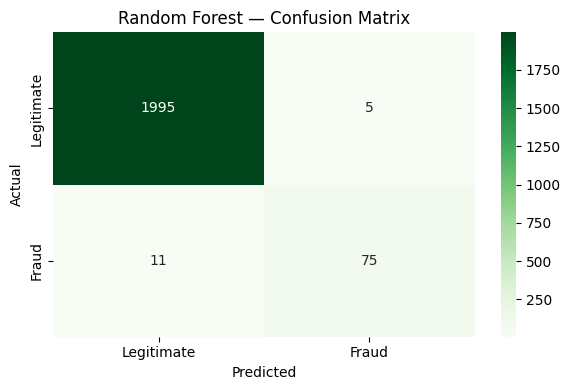


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2000
           1       0.94      0.87      0.90        86

    accuracy                           0.99      2086
   macro avg       0.97      0.93      0.95      2086
weighted avg       0.99      0.99      0.99      2086

ROC-AUC Score:  0.9899
PR-AUC  Score:  0.9238


In [8]:
# Evaluate Random Forest
print("RANDOM FOREST EVALUATION")
print("="*50)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
print(f"\nConfusion Matrix:")
print(rf_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Scores
rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)
print(f"ROC-AUC Score:  {rf_roc:.4f}")
print(f"PR-AUC  Score:  {rf_pr:.4f}")

XGBOOST EVALUATION

Confusion Matrix:
[[1981   19]
 [  11   75]]


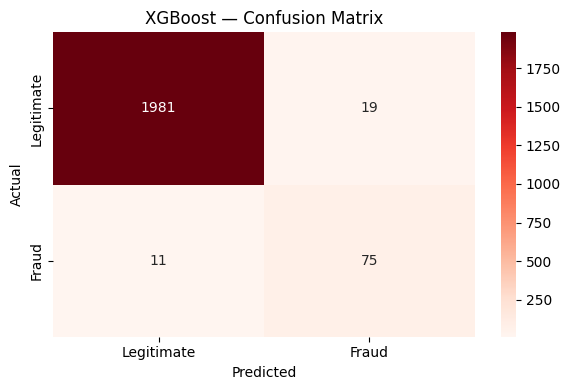


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2000
           1       0.80      0.87      0.83        86

    accuracy                           0.99      2086
   macro avg       0.90      0.93      0.91      2086
weighted avg       0.99      0.99      0.99      2086

ROC-AUC Score:  0.9813
PR-AUC  Score:  0.9115


In [9]:
# Evaluate XGBoost
print("XGBOOST EVALUATION")
print("="*50)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(f"\nConfusion Matrix:")
print(xgb_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred))

# Scores
xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_pr = average_precision_score(y_test, xgb_prob)
print(f"ROC-AUC Score:  {xgb_roc:.4f}")
print(f"PR-AUC  Score:  {xgb_pr:.4f}")

GRADIENT BOOSTING EVALUATION

Confusion Matrix:
[[1982   18]
 [  11   75]]


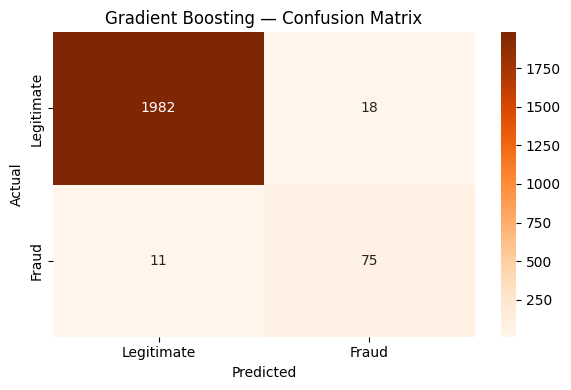


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2000
           1       0.81      0.87      0.84        86

    accuracy                           0.99      2086
   macro avg       0.90      0.93      0.92      2086
weighted avg       0.99      0.99      0.99      2086

ROC-AUC Score:  0.9799
PR-AUC  Score:  0.9136


In [10]:
# Evaluate Gradient Boosting
print("GRADIENT BOOSTING EVALUATION")
print("="*50)

# Predictions
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
gb_cm = confusion_matrix(y_test, gb_pred)
print(f"\nConfusion Matrix:")
print(gb_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    gb_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, gb_pred))

# Scores
gb_roc = roc_auc_score(y_test, gb_prob)
gb_pr = average_precision_score(y_test, gb_prob)
print(f"ROC-AUC Score:  {gb_roc:.4f}")
print(f"PR-AUC  Score:  {gb_pr:.4f}")

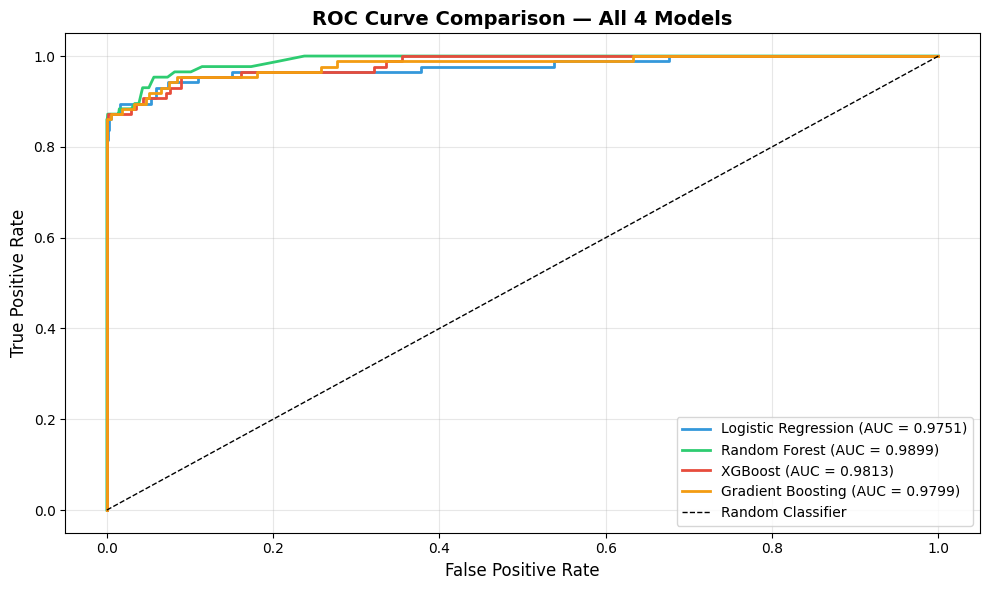

✅ ROC Curve saved!


In [11]:
# ROC Curve Comparison All 4 Models
plt.figure(figsize=(10, 6))

models_probs = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "Gradient Boosting": gb_prob
}

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, prob), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC Curve saved!")

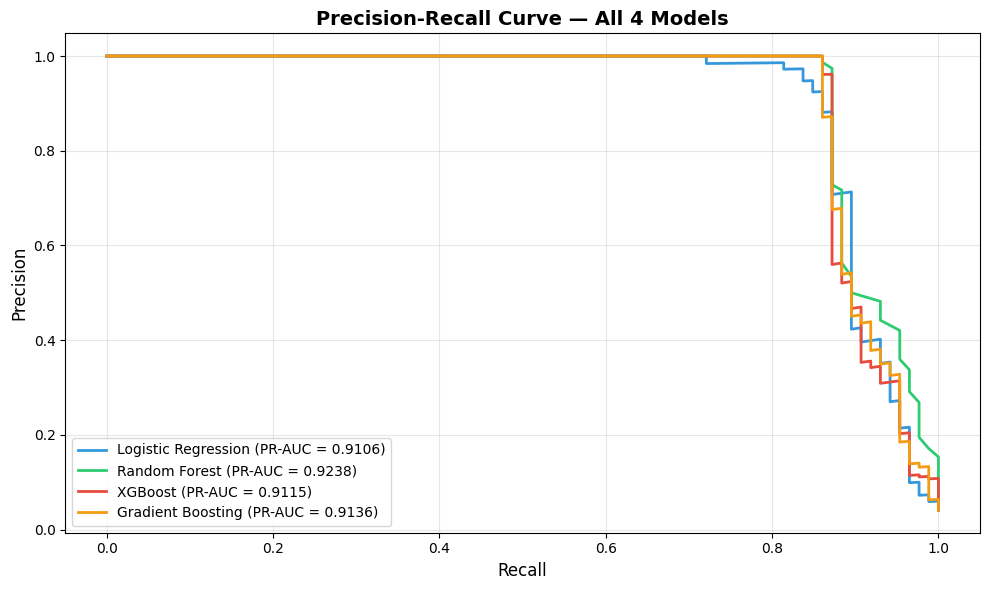

✅ PR Curve saved!


In [12]:
# Precision Recall Curve Comparison  All 4 Models
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))

models_probs = {
    "Logistic Regression": lr_prob,
    "Random Forest":       rf_prob,
    "XGBoost":             xgb_prob,
    "Gradient Boosting":   gb_prob
}

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, prob), color in zip(models_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, color=color, linewidth=2,
             label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall',    fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PR Curve saved!")

In [13]:
# Model Comparison Summary — Real Results
comparison_data = {
    'Model':             ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Precision (Fraud)': [0.51, 0.94, 0.80, 0.81],
    'Recall (Fraud)':    [0.90, 0.87, 0.87, 0.87],
    'F1-Score (Fraud)':  [0.65, 0.90, 0.83, 0.84],
    'Accuracy':          [0.96, 0.99, 0.99, 0.99],
    'ROC-AUC':           [0.9751, 0.9899, 0.9813, 0.9799],
    'PR-AUC':            [0.9106, 0.9238, 0.9115, 0.9136],
    'False Negatives':   [9, 11, 11, 11]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 95)
print("                    MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 95)
print(comparison_df.to_string(index=False))
print("=" * 95)
print("\n🏆 Best Model: Random Forest — Highest ROC-AUC (0.9899) and PR-AUC (0.9238)")

                    MODEL PERFORMANCE COMPARISON TABLE
              Model  Precision (Fraud)  Recall (Fraud)  F1-Score (Fraud)  Accuracy  ROC-AUC  PR-AUC  False Negatives
      Random Forest               0.94            0.87              0.90      0.99   0.9899  0.9238               11
            XGBoost               0.80            0.87              0.83      0.99   0.9813  0.9115               11
  Gradient Boosting               0.81            0.87              0.84      0.99   0.9799  0.9136               11
Logistic Regression               0.51            0.90              0.65      0.96   0.9751  0.9106                9

🏆 Best Model: Random Forest — Highest ROC-AUC (0.9899) and PR-AUC (0.9238)


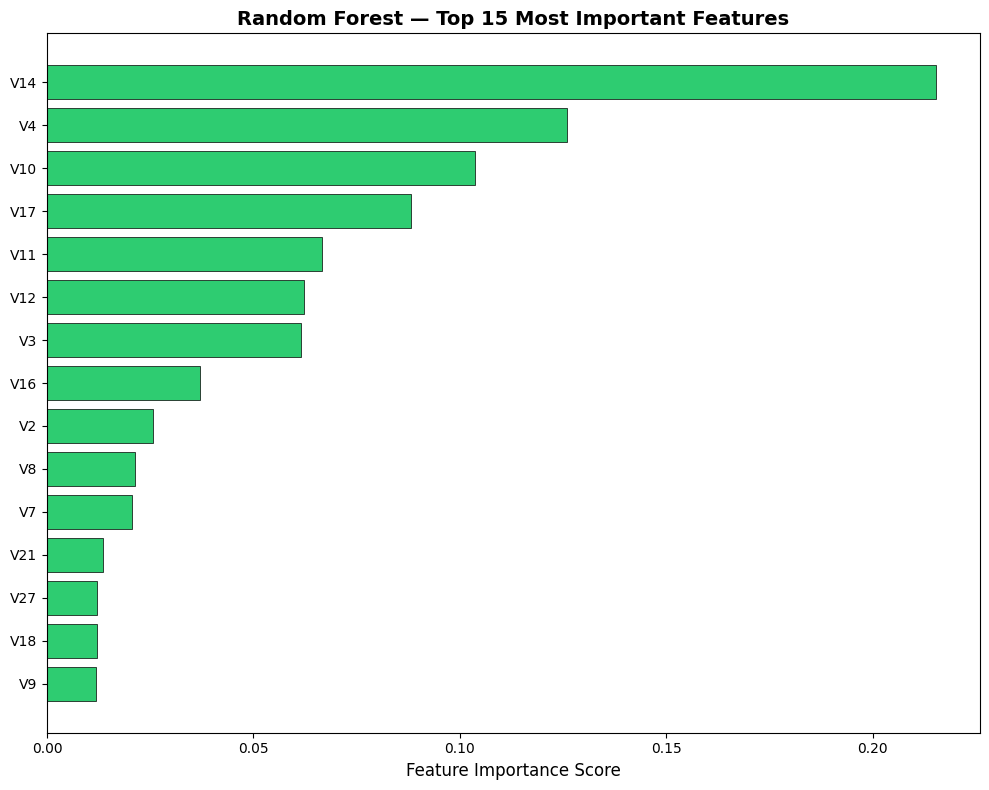

✅ Feature importance plot saved!


In [15]:
# Feature Importance — Random Forest
plt.figure(figsize=(10, 8))

# Get feature importances
importance = rf_model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'V{i}' for i in range(X_train.shape[1])]

# Sort by importance
indices = np.argsort(importance)[::-1][:15]

plt.barh(
    range(len(indices)),
    importance[indices],
    color='#2ecc71',
    edgecolor='black',
    linewidth=0.5
)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Random Forest — Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved!")

In [16]:
import joblib
import os

# Create backend directory if it doesn't exist
os.makedirs('../backend', exist_ok=True)

# Save the best model
joblib.dump(rf_model, '../backend/fraud_model.pkl')
print("✅ Best model (Random Forest) saved to: ../backend/fraud_model.pkl")

# Verify it saved correctly by reloading and testing it
loaded_model = joblib.load('../backend/fraud_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
test_prob = loaded_model.predict_proba(X_test[:5])[:, 1]

print(f"✅ Model reloaded successfully!")
print(f"   Sample predictions:   {test_pred}")
print(f"   Sample probabilities: {[round(p, 4) for p in test_prob]}")
print(f"   File size: {os.path.getsize('../backend/fraud_model.pkl') / 1024:.1f} KB")

✅ Best model (Random Forest) saved to: ../backend/fraud_model.pkl
✅ Model reloaded successfully!
   Sample predictions:   [0 0 0 0 0]
   Sample probabilities: [np.float64(0.12), np.float64(0.02), np.float64(0.04), np.float64(0.02), np.float64(0.0)]
   File size: 4366.4 KB
